# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [14]:
%load_ext IPython.extensions.autoreload
%autoreload 2

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [15]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [16]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


In [17]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: []
❌ No GPU detected


In [18]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


## Cargar datos fuente de entrenamiento


In [19]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [20]:
REGENERATE_MODEL = True


In [21]:
src_dir_boolean = spark_utils.path(
    'final_training_data_rating_array_boolean_categories', catalog = GOLD_PREMODELING
)


In [22]:
categories = spark.read.parquet(src_dir_boolean).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

In [14]:
from src.utils.models import BinaryModelCategory
binary_model = BinaryModelCategory(
    'binary_model_category', 
    METASTORE_PATH, 
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_boolean,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    n_categories=len(categories),
    n_main_features=400
)
binary_model.prepare_data(
    target_columns=[b"rating_boolean"], 
    category_columns=categories,
    shuffle_buffer_size=-1,
    batch_size=1024,
)

## Crear modelo de predicción


In [11]:
binary_model.create_model()

<Functional name=functional, built=True>

In [18]:
binary_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model_with_categories.png"
)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_with_categories.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_with_categories.png'

In [19]:
binary_model.input_shape

In [11]:
binary_model.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    102,656 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 256)       │          0 │ dense_256[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │     32,896 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 128)       │          0 │ dense_128[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      8,256 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 64)        │          0 │ dense_64[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 41)        │          0 │ dense_32[0][0],   │
│ (Concatenate)       │                   │            │ category_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 16)        │        672 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8)         │        136 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          9 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,705 (573.07 KB)

 Trainable params: 146,705 (573.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
if True:
    history_model_binary = binary_model.train(epochs=10)


Epoch 1/10
   4170/Unknown 1093s 228ms/step - accuracy: 0.8571 - loss: 0.3572

2025-11-16 18:58:38.492619: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.27376, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_category/model_checkpoints/rating_model_epoch_01.h5


2025-11-16 19:01:27.154556: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1261s 268ms/step - accuracy: 0.8802 - loss: 0.3090 - val_accuracy: 0.8863 - val_loss: 0.2738 - learning_rate: 0.0010
Epoch 2/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8949 - loss: 0.2594
Epoch 2: val_loss improved from 0.27376 to 0.24647, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_category/model_checkpoints/rating_model_epoch_02.h5


...

4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1137s 271ms/step - accuracy: 0.9245 - loss: 0.1890 - val_accuracy: 0.9325 - val_loss: 0.1720 - learning_rate: 0.0010
Epoch 7/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9271 - loss: 0.1827
Epoch 7: val_loss improved from 0.17200 to 0.16540, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_category/model_checkpoints/rating_model_epoch_07.h5


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1153s 275ms/step - accuracy: 0.9283 - loss: 0.1803 - val_accuracy: 0.9355 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 8/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9301 - loss: 0.1756
Epoch 8: val_loss improved from 0.16540 to 0.15749, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_category/model_checkpoints/rating_model_epoch_08.h5


2025-11-16 21:16:23.708687: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1196s 285ms/step - accuracy: 0.9312 - loss: 0.1733 - val_accuracy: 0.9398 - val_loss: 0.1575 - learning_rate: 0.0010
Epoch 9/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9325 - loss: 0.1702
Epoch 9: val_loss improved from 0.15749 to 0.15139, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_category/model_checkpoints/rating_model_epoch_09.h5


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1164s 278ms/step - accuracy: 0.9335 - loss: 0.1681 - val_accuracy: 0.9423 - val_loss: 0.1514 - learning_rate: 0.0010
Epoch 10/10
3026/4170 ━━━━━━━━━━━━━━━━━━━━ 13:04 686ms/step - accuracy: 0.9346 - loss: 0.1646

2025/11/16 22:44:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 22:44:19 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/16 22:44:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


b4431b779a41466696f33a1dae0d9daf
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_model.png


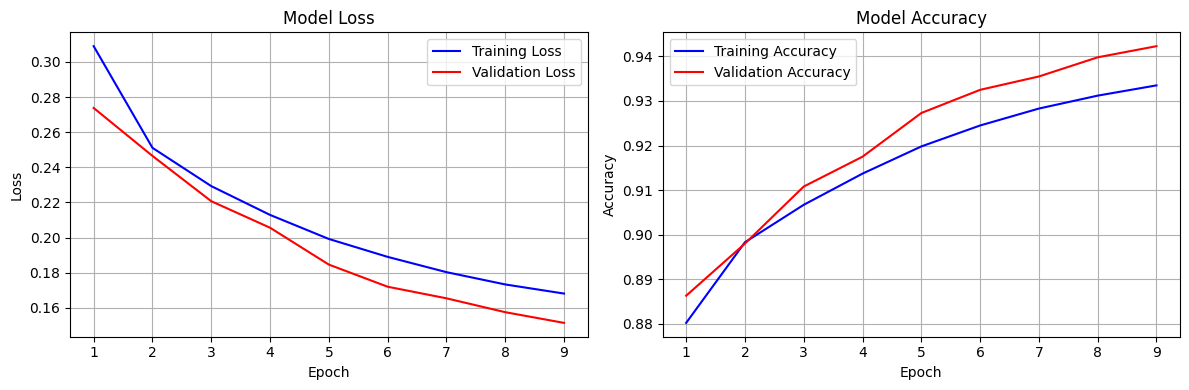

In [18]:
if True:
    for name, model in [
        ("binary_model", binary_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [10]:
from src.utils.models import BinaryModelCategory
binary_model = BinaryModelCategory(
    'binary_model_category', 
    METASTORE_PATH, 
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_boolean,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    n_categories=len(categories),
    n_main_features=400
)
binary_model.prepare_data(
    target_columns=[b"rating_boolean"], 
    category_columns=categories,
    shuffle_buffer_size=-1,
    batch_size=1024,
)

2025-11-16 23:22:48.165384: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


In [11]:
binary_model.load_latest_model()

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Using cached evaluation results
Confusion matrix saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_category/confusion_matrix.png
Error logging confusion matrix to MLflow: Could not find experiment with ID 0


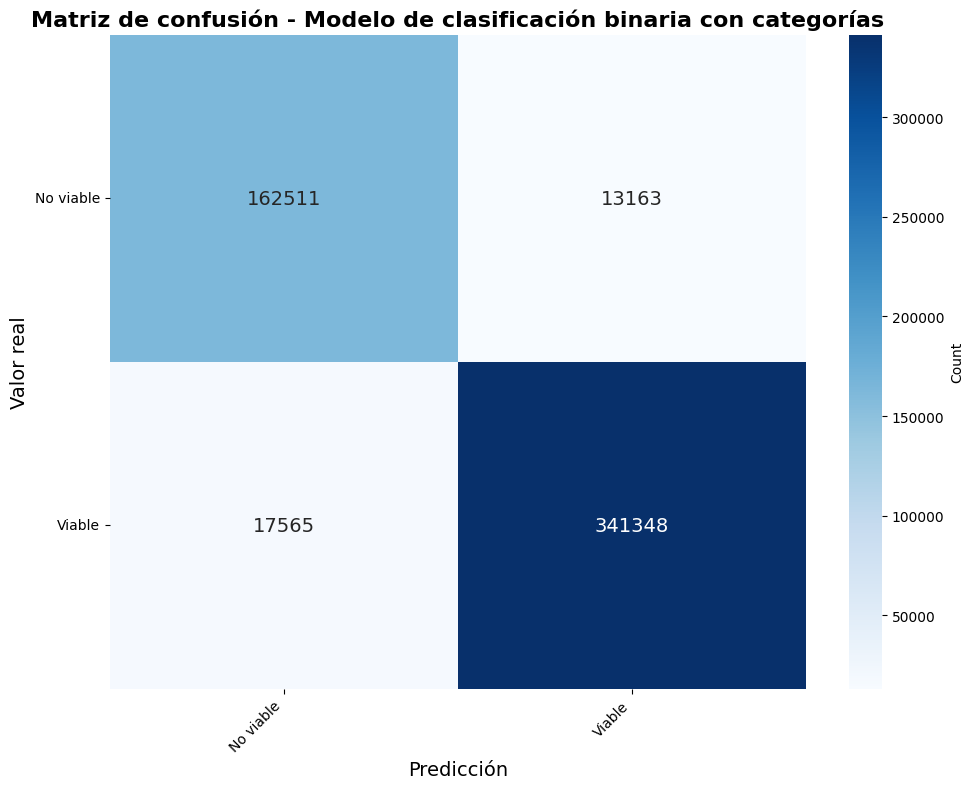

array([[162511,  13163],
       [ 17565, 341348]])

In [13]:
binary_model.plot_confusion_matrix(
    title = 'Matriz de confusión - Modelo de clasificación binaria con categorías',
    class_names = ['No viable', 'Viable'],
    xlabel = 'Predicción',
    ylabel = 'Valor real',
    annot_fontsize = 14,
    label_fontsize = 14,
)

In [25]:
from src.utils.models import BinaryModelCategory
binary_model = BinaryModelCategory(
    'binary_model_category', 
    METASTORE_PATH, 
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_boolean,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    n_categories=len(categories),
    n_main_features=400
)
binary_model.create_model()
binary_model.model.summary()
binary_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model_with_categories.png",
    levels = 4
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    102,656 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 256)       │          0 │ dense_256[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │     32,896 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 128)       │          0 │ dense_128[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      8,256 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 64)        │          0 │ dense_64[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 41)        │          0 │ dense_32[0][0],   │
│ (Concatenate)       │                   │            │ category_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 16)        │        672 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8)         │        136 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          9 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,705 (573.07 KB)

 Trainable params: 146,705 (573.07 KB)

 Non-trainable params: 0 (0.00 B)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_with_categories.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model_with_categories.png'

In [ ]:
binary_model.list_available_models()



Available Model Versions (filtered by: binary_model)

1. Run ID: a160b18118644060b3873c876b1cc488
   Run Name: binary_model_402features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-15 23:19:06.017000+00:00
   End Time: 2025-11-15 23:19:22.497000+00:00
   Metrics: Loss: 0.3076, Val Loss: 0.2752, Accuracy: 0.8640, Val Accuracy: 0.8878

2. Run ID: da62db697dc14ee896de1a84588f60ce
   Run Name: binary_model_376features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-04 04:47:56.442000+00:00
   End Time: 2025-11-04 04:48:10.334000+00:00
   Metrics: Loss: 0.0883, Val Loss: 0.4196, Accuracy: 0.9625, Val Accuracy: 0.8926

3. Run ID: 3d22f578699344afbf70825e7d74c9dc
   Run Name: binary_model_401features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-27 02:21:00.431000+00:00
   End Time: 2025-10-27 02:21:14.596000+00:00
   Metrics: Loss: 0.0650, Val Loss: 0.0420, Accuracy: 0.9717, Val Accuracy: 0.9831

4. Run ID: 195df4651b0e4630bb7a59963e15babe
   Run Name: 

In [ ]:
binary_model.load_latest_model()

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_binary_model.png


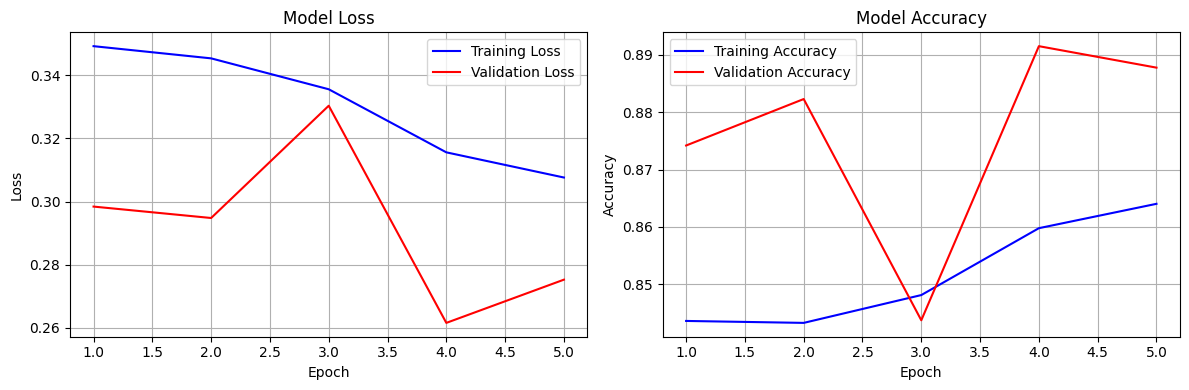

In [ ]:
binary_model.plot_latest_model_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_binary_{'binary_model'}.png"
        )

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/old_training_history_binary_binary_model.png


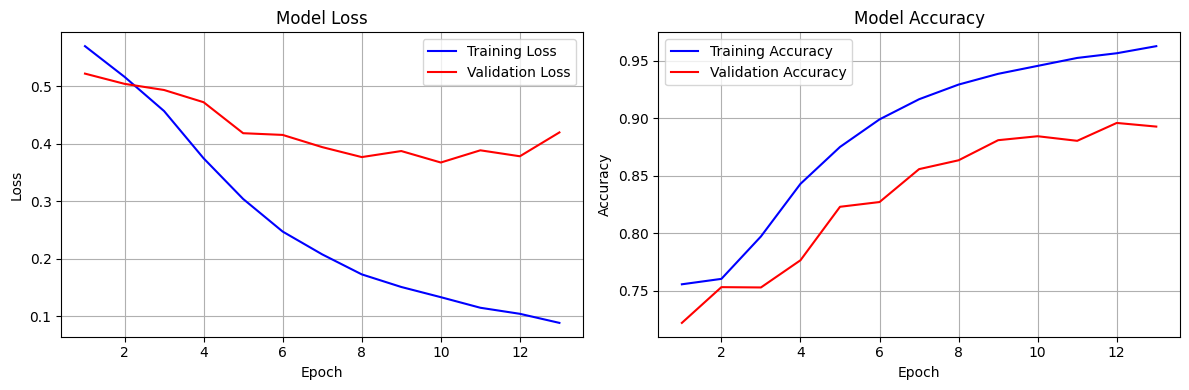

In [ ]:
binary_model.load_model(run_id='da62db697dc14ee896de1a84588f60ce')
binary_model.plot_training_history(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/old_training_history_binary_{'binary_model'}.png"
)